## Import liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)
from pandas.tseries.offsets import MonthEnd

In [2]:
from prophet import Prophet
from xgboost import XGBRegressor

In [3]:
df=pd.read_csv("/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv", encoding="cp1252")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])
df["Order Month"]=df["Order Date"].dt.month
df["Ship Month"]=df["Ship Date"].dt.month
df["Order Year"]=df["Order Date"].dt.year
df["Ship Year"]=df["Ship Date"].dt.year

df["Shipping Days"]=(df["Ship Date"]-df["Order Date"]).dt.days
df["Quarter"]=df["Order Date"].dt.quarter
df[["Order Date","Ship Date","Order Month","Ship Month", "Order Year","Ship Year","Shipping Days","Quarter"]].head()

,Order Date,Ship Date,Order Month,Ship Month,Order Year,Ship Year,Shipping Days,Quarter
0,2016-11-08,2016-11-11,11,11,2016,2016,3,4
1,2016-11-08,2016-11-11,11,11,2016,2016,3,4
2,2016-06-12,2016-06-16,6,6,2016,2016,4,2
3,2015-10-11,2015-10-18,10,10,2015,2015,7,4
4,2015-10-11,2015-10-18,10,10,2015,2015,7,4


In [5]:
# cycling encoding for month
df["month_sin"] = np.sin(2 * np.pi * df["Order Month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Order Month"] / 12)

In [6]:
drop_cols=['Row ID','Order ID', 'Ship Date','Customer ID', 'Customer Name',
              'Country', 'Postal Code', 'Product ID', 'Product Name',]

one_encoded_cols=['Ship Mode', 'Segment', 'State', 'Region', 'Category','Sub-Category']

In [7]:
df.sort_values(by='Order Date', inplace=True)

df.reset_index(drop=True, inplace=True)

## Prophet Model

In [8]:
df_prophet = df[['Order Date', 'Sales']].copy()
df_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)
df_prophet=df_prophet.groupby('ds')['y'].sum().reset_index()

In [9]:
train = df_prophet.iloc[:-60]
test = df_prophet.iloc[-60:]

In [10]:
model = Prophet(yearly_seasonality=True)
model.fit(train)

04:46:13 - cmdstanpy - INFO - Chain [1] start processing
04:46:13 - cmdstanpy - INFO - Chain [1] done processing


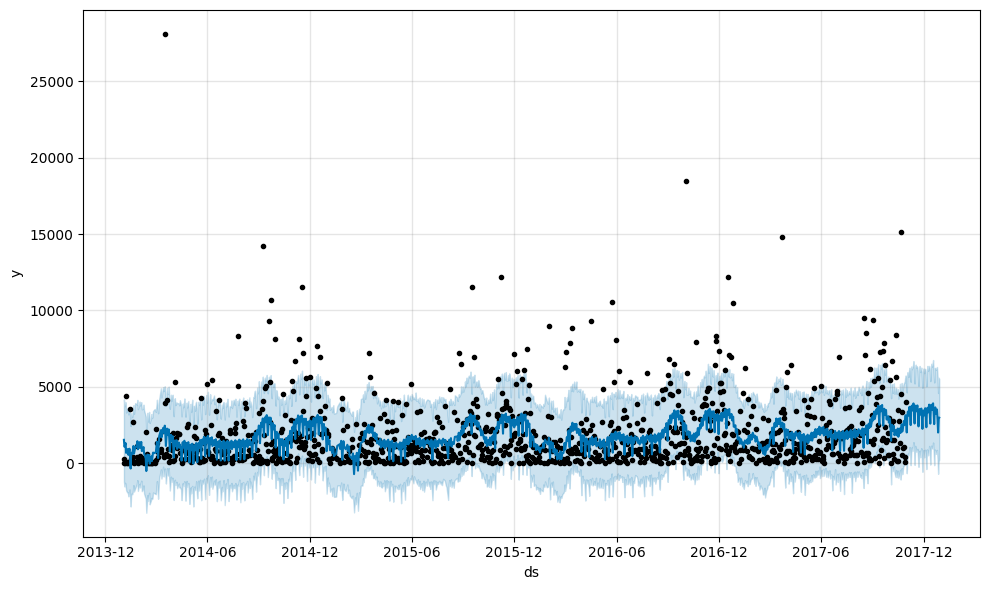

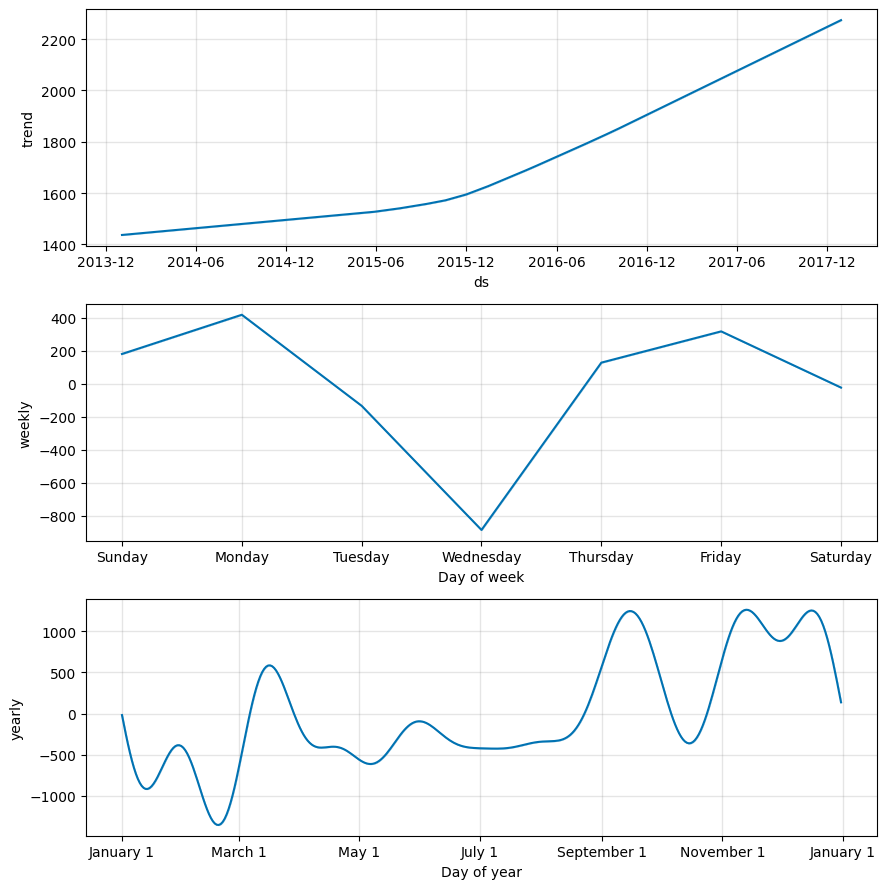

In [11]:
future = model.make_future_dataframe(periods=60)

# Predict
forecast = model.predict(future)

# Plot
model.plot(forecast)

# Extract predictions for test period
pred = forecast[['ds', 'yhat']].tail(60)

# Align properly
merged = pd.merge(test, pred, on='ds')
prophet_rmse=root_mean_squared_error(merged['y'], merged['yhat'])
plt.show()

# Plot components (trend, seasonality)
model.plot_components(forecast)
plt.show()

In [12]:
#Extract predictions specifically for the test period
# Filter forecast to match only the dates present in your test set
pred = forecast[['ds', 'yhat']]

# 4. Merge test data and predictions on the date column ('ds')
# This ensures you are comparing the actual 'y' and predicted 'yhat' for the exact same days
merged = pd.merge(test, pred, on='ds')

# 5. Calculate RMSE
prophet_rmse = root_mean_squared_error(merged['y'], merged['yhat'])
prophet_rmse

2688.8326516112443

## Prophet model 2 (with regressors)

In [13]:
model2 = Prophet(yearly_seasonality=True)
model2.add_regressor('discount')
model2.add_regressor('quantity')
model2.add_regressor('shipping_days')

# train2=df_prophet['']

In [16]:
train2=df[['Order Date','Sales','Discount','Quantity','Shipping Days']]

In [17]:
train2.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)

/tmp/ipykernel_58/694627257.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)


In [18]:
train2=train2.groupby('ds')['y'].sum().reset_index()

## XGBoost model

In [9]:
df2=df.copy()

In [20]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Date", "Sales"]
monthly_sales.reset_index(inplace=True)

In [21]:
df2.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Month', 'Ship Month', 'Order Year', 'Ship Year', 'Shipping Days',
       'Quarter', 'month_sin', 'month_cos'],
      dtype='object')

In [22]:
def create_features(data):

    df = data.copy()

    # Lag Features
    df["lag_1"] = df["Sales"].shift(1)
    df["lag_3"] = df["Sales"].shift(3)
    df["lag_6"] = df["Sales"].shift(6)
    df["lag_12"] = df["Sales"].shift(12)

    # Rolling Means
    df["roll_mean_3"] = df["Sales"].shift(1).rolling(3).mean()
    df["roll_mean_6"] = df["Sales"].shift(1).rolling(6).mean()
    df["roll_mean_12"] = df["Sales"].shift(1).rolling(12).mean()

    # Rolling Std
    df["roll_std_3"] = df["Sales"].shift(1).rolling(3).std()
    df["roll_std_6"] = df["Sales"].shift(1).rolling(6).std()

    # Date Features
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["year"] = df["Date"].dt.year

    return df

In [23]:
monthly_sales = create_features(monthly_sales)
# monthly_sales = monthly_sales.fillna()
monthly_sales.head()

,index,Date,Sales,lag_1,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_mean_12,roll_std_3,roll_std_6,month,quarter,year
0,0,2014-01-01,14236.895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2014
1,1,2014-02-01,4519.892,14236.895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,2014
2,2,2014-03-01,55691.009,4519.892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,2014
3,3,2014-04-01,28295.345,55691.009,14236.895,NaN,NaN,24815.932,NaN,NaN,27176.420324,NaN,4,2,2014
4,4,2014-05-01,23648.287,28295.345,4519.892,NaN,NaN,29502.082,NaN,NaN,25606.892908,NaN,5,2,2014


In [10]:
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:train_size]
test = monthly_sales.iloc[train_size:]

NameError: name 'monthly_sales' is not defined

In [8]:
FEATURES = [
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "roll_mean_3",
    "roll_mean_6",
    "roll_mean_12",
    "roll_std_3",
    "roll_std_6",
    "month",
    "quarter",
    "year"
]

TARGET = "Sales"

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

NameError: name 'train' is not defined

In [26]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 12464.570523125
RMSE: 15074.375948714505
R²: 0.5997660652072438


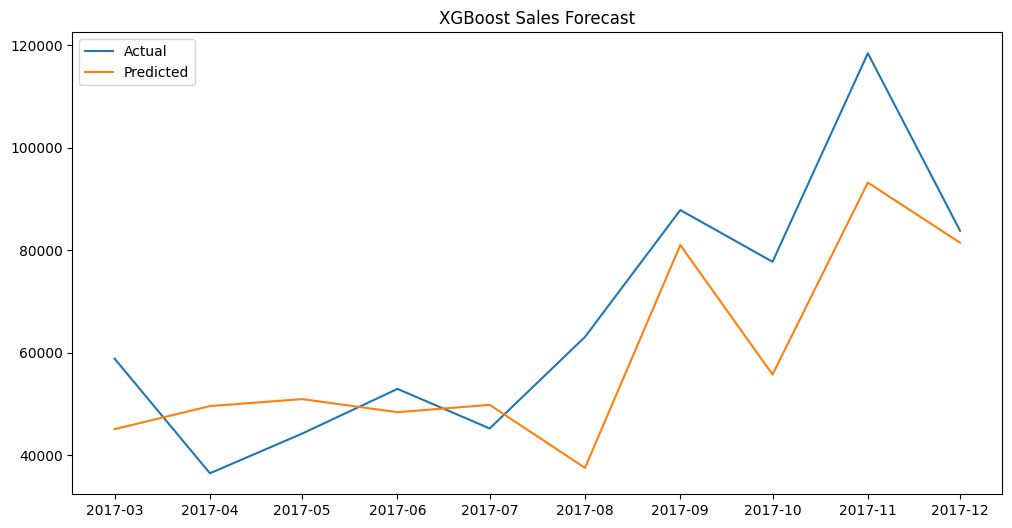

In [28]:
plt.figure(figsize=(12,6))

plt.plot(test["Date"], y_test, label="Actual")
plt.plot(test["Date"], preds, label="Predicted")

plt.legend()
plt.title("XGBoost Sales Forecast")
plt.show()

In [29]:
future_periods = 12
future_df = monthly_sales.copy()

future_predictions = []

for i in range(future_periods):

    last_date = future_df["Date"].max()

    next_date = last_date + pd.DateOffset(months=1)

    temp = pd.DataFrame({
        "Date": [next_date]
    })

    combined = pd.concat([future_df, temp], ignore_index=True)

    combined = create_features(combined)

    X_future = combined.iloc[-1:][FEATURES]

    pred = model.predict(X_future)[0]

    temp["Sales"] = pred

    future_predictions.append([next_date, pred])

    future_df = pd.concat([future_df, temp], ignore_index=True)

future_forecast = pd.DataFrame(
    future_predictions,
    columns=["Date", "Forecasted_Sales"]
)

print(future_forecast)

         Date  Forecasted_Sales
0  2018-01-01      40689.812500
1  2018-02-01      36900.195312
2  2018-03-01      47120.511719
3  2018-04-01      48556.492188
4  2018-05-01      49105.570312
5  2018-06-01      48729.777344
6  2018-07-01      52268.867188
7  2018-08-01      48285.378906
8  2018-09-01      81162.476562
9  2018-10-01      79133.570312
10 2018-11-01      89212.984375
11 2018-12-01      87481.718750


## XGBoost model 2 (with wieghted discount, month sin & cos)

In [9]:
monthly_sales2=df.resample('ME', on='Order Date').apply(
    lambda x:pd.Series({
        'Sales': x['Sales'].sum(),
        'Profit': x['Profit'].sum(),
        'Weighted_discount': (x['Sales']*x['Discount']).sum()/x['Sales'].sum()
    })
)
monthly_sales2.reset_index(inplace=True)

In [10]:
monthly_sales2['Month_sin']=np.sin(2*np.pi*(monthly_sales2['Order Date'].dt.month)/12)
monthly_sales2['Month_cos']=np.cos(2*np.pi*(monthly_sales2['Order Date'].dt.month)/12)
monthly_sales2['Month_Quarter']=monthly_sales2['Order Date'].dt.quarter

monthly_sales2['Sales_MA_3'] = monthly_sales2['Sales'].rolling(window=3).mean() #.fillna(0)
monthly_sales2['Sales_MA_6'] = monthly_sales2['Sales'].rolling(window=6).mean() #.fillna(0)
monthly_sales2['Sales_MA_12']= monthly_sales2['Sales'].rolling(window=12).mean()

monthly_sales2['Lag_3']=monthly_sales2['Sales'].shift(3)
monthly_sales2['Lag_6']=monthly_sales2['Sales'].shift(6)
monthly_sales2['Lag_12']=monthly_sales2['Sales'].shift(12)

monthly_sales2["Rolling_Std_3"] = (monthly_sales2["Sales"].shift(1).rolling(window=3).std())
monthly_sales2["Rolling_Std_6"] = (monthly_sales2["Sales"].shift(1).rolling(window=6).std())
monthly_sales2["Rolling_Std_12"] = (monthly_sales2["Sales"].shift(1).rolling(window=12).std())

In [11]:
monthly_sales2.columns

Index(['Order Date', 'Sales', 'Profit', 'Weighted_discount', 'Month_sin',
       'Month_cos', 'Month_Quarter', 'Sales_MA_3', 'Sales_MA_6', 'Sales_MA_12',
       'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Std_3', 'Rolling_Std_6',
       'Rolling_Std_12'],
      dtype='object')

In [12]:
feature2=['Month_sin','Month_cos', 'Month_Quarter', 'Sales_MA_3', 'Sales_MA_6',
        'Sales_MA_12', 'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Std_3', 'Rolling_Std_6',
       'Rolling_Std_12']

In [13]:
train_size = int(len(monthly_sales2) * 0.8)

train2 = monthly_sales2.iloc[:train_size]
test2 = monthly_sales2.iloc[train_size:]

In [14]:
TARGET = "Sales"
X_train2 = train2[feature2]
y_train2 = train2[TARGET]

X_test2 = test2[feature2]
y_test2 = test2[TARGET]

In [15]:
model2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model2.fit(X_train2, y_train2)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
pred2=model2.predict(X_test2)

mae2=mean_absolute_error(y_test2, pred2)
rmse2=mean_squared_error(y_test2, pred2) ** 0.5
r2_xgb2=r2_score(y_test2, pred2)

print("MAE XGB2:", mae2)
print("RMSE XGB2:", rmse2)
print("R2 XGB2:", r2_xgb2)

MAE XGB2: 8526.594428125
RMSE XGB2: 11181.337956537032
R2 XGB2: 0.7797972326053306


In [17]:
test2.columns

Index(['Order Date', 'Sales', 'Profit', 'Weighted_discount', 'Month_sin',
       'Month_cos', 'Month_Quarter', 'Sales_MA_3', 'Sales_MA_6', 'Sales_MA_12',
       'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Std_3', 'Rolling_Std_6',
       'Rolling_Std_12'],
      dtype='object')

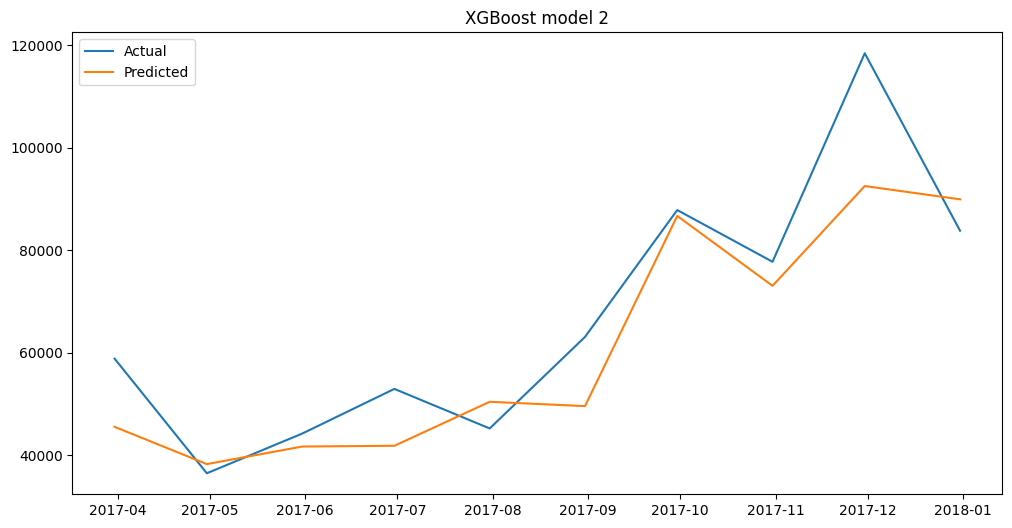

In [18]:
plt.figure(figsize=(12,6))

plt.plot(test2["Order Date"], y_test2, label="Actual")
plt.plot(test2["Order Date"], pred2, label="Predicted")

plt.legend()
plt.title("XGBoost model 2")
plt.show()

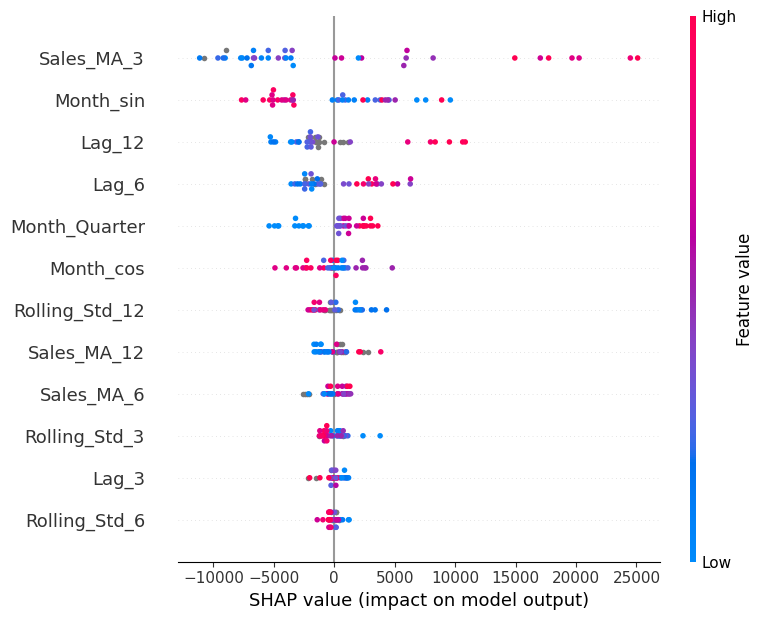

In [39]:
import shap
explainer=shap.TreeExplainer(model2)
shap_values=explainer.shap_values(X_train2)
shap.summary_plot(shap_values, X_train2)

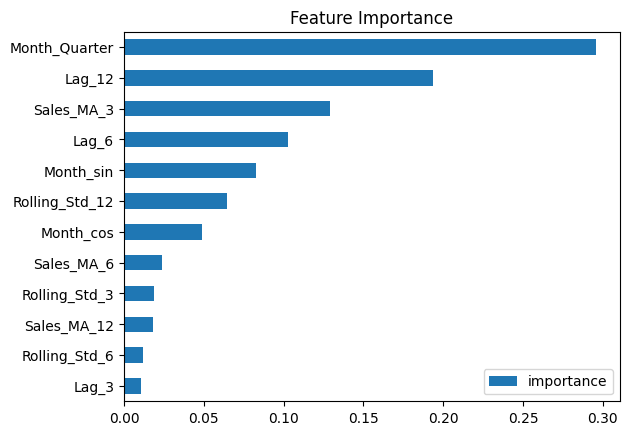

In [40]:
fi=pd.DataFrame(model2.feature_importances_,
               index=model2.feature_names_in_,
               columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

## XGB model 3 (fine tuning model 2)

In [19]:
model3 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

In [20]:
model3.fit(X_train2, y_train2,
          eval_set=[(X_train2, y_train2),(X_test2, y_test2)], verbose=50)

[0]	validation_0-rmse:22057.00009	validation_1-rmse:33105.39558
[50]	validation_0-rmse:4865.79800	validation_1-rmse:14755.89715
[100]	validation_0-rmse:1694.73543	validation_1-rmse:11897.49776
[150]	validation_0-rmse:674.20231	validation_1-rmse:11014.53932
[200]	validation_0-rmse:268.87276	validation_1-rmse:10843.50201
[250]	validation_0-rmse:114.35869	validation_1-rmse:10771.61951
[300]	validation_0-rmse:46.59750	validation_1-rmse:10762.11545
[347]	validation_0-rmse:22.01761	validation_1-rmse:10762.06215


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

MAE XGB3: 7982.344496874999
RMSE XGB3: 10760.823642046495
R2 XGB3: 0.7960488061421216


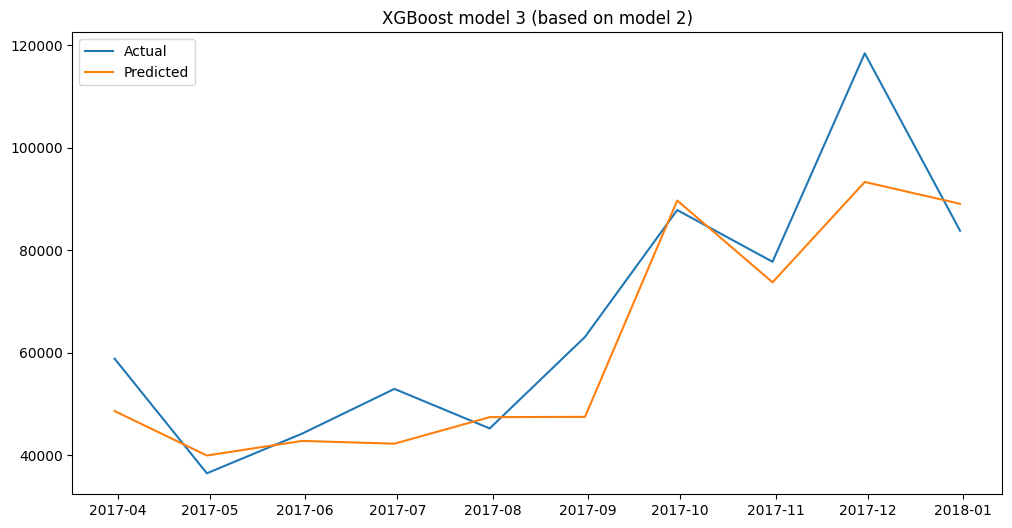

In [21]:
pred3=model3.predict(X_test2)

mae3=mean_absolute_error(y_test2, pred3)
rmse3=mean_squared_error(y_test2, pred3) ** 0.5
r2_xgb3=r2_score(y_test2, pred3)

print("MAE XGB3:", mae3)
print("RMSE XGB3:", rmse3)
print("R2 XGB3:", r2_xgb3)

plt.figure(figsize=(12,6))

plt.plot(test2["Order Date"], y_test2, label="Actual")
plt.plot(test2["Order Date"], pred3, label="Predicted")

plt.legend()
plt.title("XGBoost model 3 (based on model 2)")
plt.show()

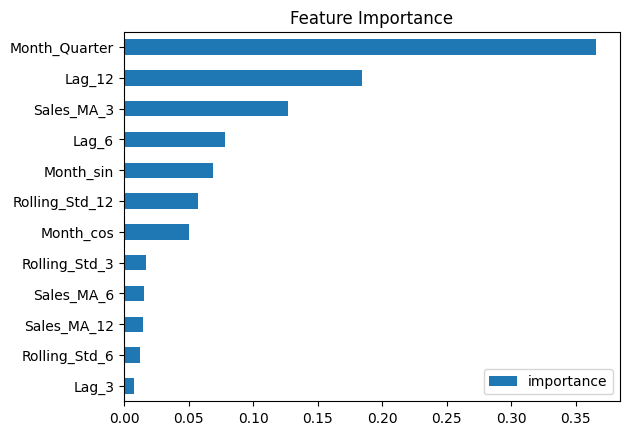

In [22]:
fi2=pd.DataFrame(model3.feature_importances_,
               index=model3.feature_names_in_,
               columns=['importance'])
fi2.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

In [45]:
X_train2.columns

Index(['Month_sin', 'Month_cos', 'Month_Quarter', 'Sales_MA_3', 'Sales_MA_6',
       'Sales_MA_12', 'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_Std_3',
       'Rolling_Std_6', 'Rolling_Std_12'],
      dtype='object')

In [46]:
# import joblib
# joblib.dump(model2,'/kaggle/working/xgb_model2.pkl')
# joblib.dump(model3,'/kaggle/working/xgb_model3.pkl')

['/kaggle/working/xgb_model3.pkl']

In [23]:
model2.save_model("/kaggle/working/xgb_model2.json")
model3.save_model("/kaggle/working/xgb_model3.json")

In [24]:
def forecast_future_sales(model, monthly_sales, features, future_period=3):
    future_preds=[]
    temp_df=monthly_sales.copy() # monthly_sales is sorted by the order date (ASC)
    temp_df.drop(columns=['Profit', 'Weighted_discount'], inplace=True)
    temp_df.set_index('Order Date', inplace=True)
    
    for i in range(future_period):
        # next month date
        next_date=(temp_df.index[-1].replace(day=1) + pd.DateOffset(months=1)) + MonthEnd(0)
        #new row
        new_row=pd.DataFrame(index=[next_date])
        month=next_date.month
        #cyclic month
        new_row['Month_sin']=np.sin(2*np.pi*month/12)
        new_row['Month_cos']=np.cos(2*np.pi*month/12)
        #quarter
        new_row['Month_Quarter']=((month-1)//3)+1 # or new_row.index.max().quarter
        # Moving averages
        new_row['Sales_MA_3'] = temp_df['Sales'].tail(3).mean()
        new_row['Sales_MA_6'] = temp_df['Sales'].tail(6).mean()
        new_row['Sales_MA_12'] = temp_df['Sales'].tail(12).mean()
        # Lag features
        new_row['Lag_3'] = temp_df['Sales'].iloc[-3]
        new_row['Lag_6'] = temp_df['Sales'].iloc[-6]
        new_row['Lag_12'] = temp_df['Sales'].iloc[-12]
        # Rolling std
        new_row['Rolling_Std_3'] = temp_df['Sales'].tail(3).std()
        new_row['Rolling_Std_6'] = temp_df['Sales'].tail(6).std()
        new_row['Rolling_Std_12'] = temp_df['Sales'].tail(12).std()
        # Predict
        X_future = new_row[features]
        pred = model3.predict(X_future)[0] #it returns numpy array so for int I use: [0]
        # Store prediction
        new_row['Sales'] = pred
    
        future_preds.append(
            {'Date': next_date, 'Forecast_Sales': pred}
        )
    
        # Append prediction for recursive forecasting
        temp_df = pd.concat([temp_df, new_row])

    return pd.DataFrame(future_preds)

In [25]:
future_period=6
forecasted_sales=forecast_future_sales(model3, monthly_sales2.iloc[:-1], feature2, future_period)
# I want some over lap of forecated and past line that's why: monthly_sales2.iloc[:-1]
forecasted_sales

,Date,Forecast_Sales
0,2017-12-31,89085.882812
1,2018-01-31,52904.332031
2,2018-02-28,45168.609375
3,2018-03-31,55149.902344
4,2018-04-30,53868.957031
5,2018-05-31,54227.328125


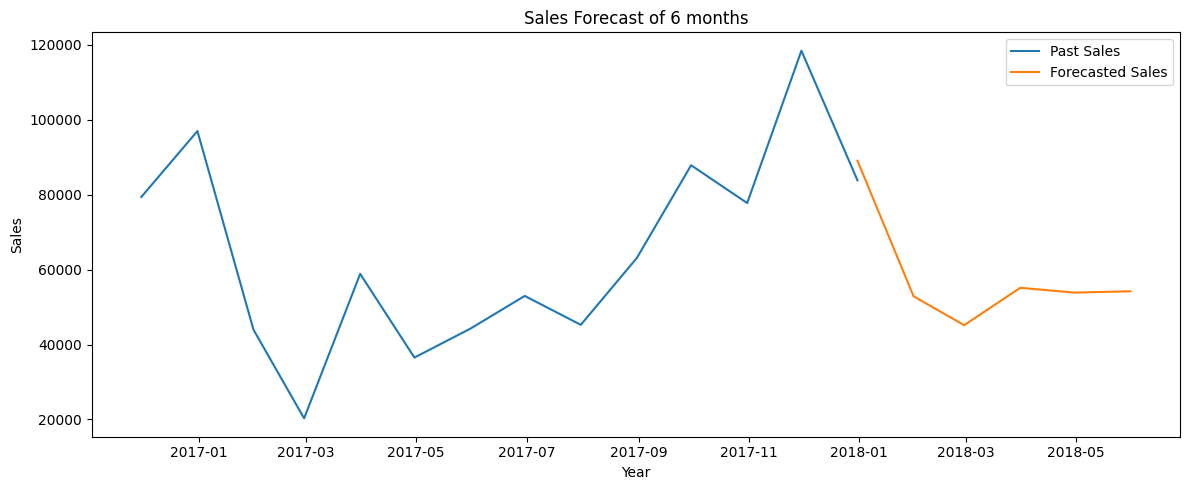

In [26]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales2['Order Date'].tail(14),monthly_sales2['Sales'].tail(14), label='Past Sales')
plt.plot(forecasted_sales['Date'],forecasted_sales['Forecast_Sales'], label='Forecasted Sales')
plt.legend()
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title(f"Sales Forecast of {future_period} months")
# plt.grid(axis="y")
plt.tight_layout()
plt.show()

## What if model (XGBoost)

In [50]:
#dropping columns
what_df=df.drop(columns=drop_cols+['Sales','Profit'])

#Frequency encoding (because city has 531 unique values)
city_fq=what_df['City'].value_counts()
what_df['City']=what_df['City'].map(city_fq)

# One-Hot encoding
what_df=pd.get_dummies(what_df, columns=one_encoded_cols)

In [51]:
from sklearn.model_selection import train_test_split
# Features
feature_cols = [
    'Quantity', 'Discount', 'Shipping Days',
    'Order Month', 'Order Year', 'Ship Month', 'Ship Year', 'City'
] + [col for col in what_df.columns if col.startswith(('Ship Mode_', 'Segment_', 'Region_', 'Category_', 'Sub-Category_', 'State_'))]

X = what_df[feature_cols]
y_sales = df['Sales']
y_profit = df['Profit']

# Train-test split
X_train, X_test, y_train_sales, y_test_sales = train_test_split(X, y_sales, test_size=0.2, random_state=42)
_, _, y_train_profit, y_test_profit = train_test_split(X, y_profit, test_size=0.2, random_state=42)

# XGBoost regressors
model_sales = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, early_stopping_rounds=50
)
model_profit = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, early_stopping_rounds=50
)


In [52]:
X_train['City'].dtype

dtype('int64')

In [53]:
# Fit models
model_sales.fit(X_train, y_train_sales, eval_set=[(X_test, y_test_sales)], verbose=50)

[0]	validation_0-rmse:689.19597
[50]	validation_0-rmse:646.68868
[77]	validation_0-rmse:649.93790


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
model_profit.fit(X_train, y_train_profit, eval_set=[(X_test, y_test_profit)], verbose=50)

[0]	validation_0-rmse:150.91210
[50]	validation_0-rmse:153.72332
[58]	validation_0-rmse:154.52480


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [55]:
model_sales_pred=model_sales.predict(X_test)
model_profit_pred=model_profit.predict(X_test)

In [56]:
# Evaluate
print("Sales RMSE:", mean_squared_error(y_test_sales, model_sales_pred)**0.5)
print("Profit RMSE:", mean_squared_error(y_test_profit, model_profit_pred)**0.5)
print("Sales R2 score: ",r2_score(y_test_sales,model_sales_pred))
print("Profit R2 score: ",r2_score(y_test_profit,model_profit_pred))

Sales RMSE: 637.4153335377815
Profit RMSE: 143.2669124027817
Sales R2 score:  0.16011908125538343
Profit R2 score:  0.12031148944352865


In [57]:
fi_model_sales=pd.DataFrame({"Feature": model_sales.feature_names_in_, "Score": model_sales.feature_importances_})
fi_model_sales.sort_values("Score", inplace=True, ascending=False)
fi_model_sales.reset_index(drop=True, inplace=True)

In [58]:
fi_model_sales.head(10)

,Feature,Score
0,Sub-Category_Copiers,0.165293
1,Sub-Category_Machines,0.102534
2,Category_Office Supplies,0.075138
3,Category_Furniture,0.047469
4,Sub-Category_Furnishings,0.044483
5,State_Indiana,0.037556
6,State_Michigan,0.033302
7,Region_East,0.033152
8,Sub-Category_Accessories,0.030580
9,State_Washington,0.024364


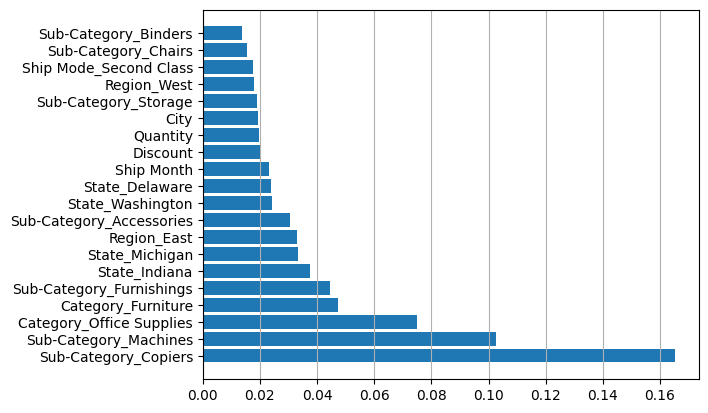

In [59]:
plt.barh(fi_model_sales['Feature'].head(20), fi_model_sales['Score'].head(20))
plt.grid(axis="x")
plt.show()

In [60]:
fi_model_sales[fi_model_sales['Score']==0.0000]

,Feature,Score
72,State_Connecticut,0.0
73,State_Colorado,0.0
74,Ship Mode_Same Day,0.0
75,State_Ohio,0.0
76,State_South Dakota,0.0
77,State_South Carolina,0.0
78,State_Missouri,0.0
79,State_Montana,0.0
80,State_Iowa,0.0
81,State_Kansas,0.0


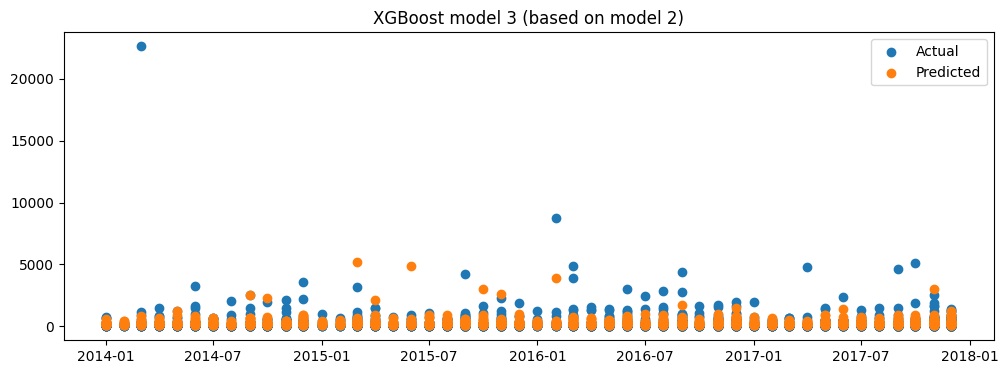

In [61]:
X_test_order_date = X_test.copy()
X_test_order_date['Order Date'] = pd.to_datetime(X_test['Order Year'].astype(str) + '-' + X_test['Order Month'].astype(str) + '-01')
plt.figure(figsize=(12,4))
plt.scatter(X_test_order_date["Order Date"], y_test_sales, label="Actual")
plt.scatter(X_test_order_date["Order Date"], model_sales_pred, label="Predicted")

plt.legend()
plt.title("XGBoost model 3 (based on model 2)")
plt.show()

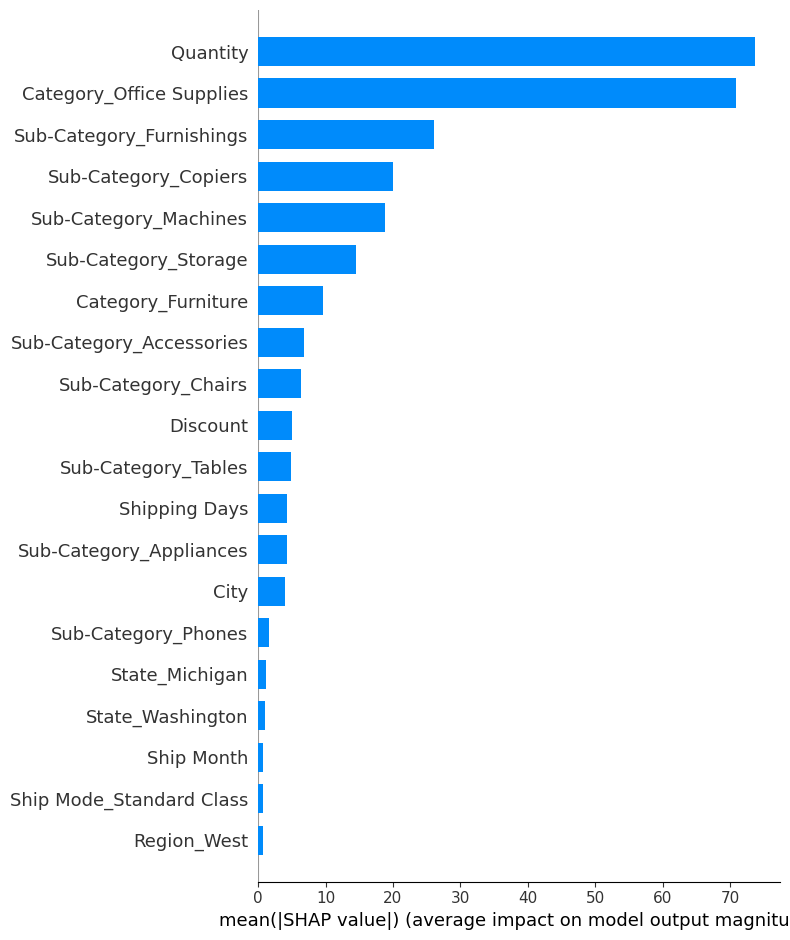

In [63]:
import shap
explainer = shap.TreeExplainer(model_sales)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

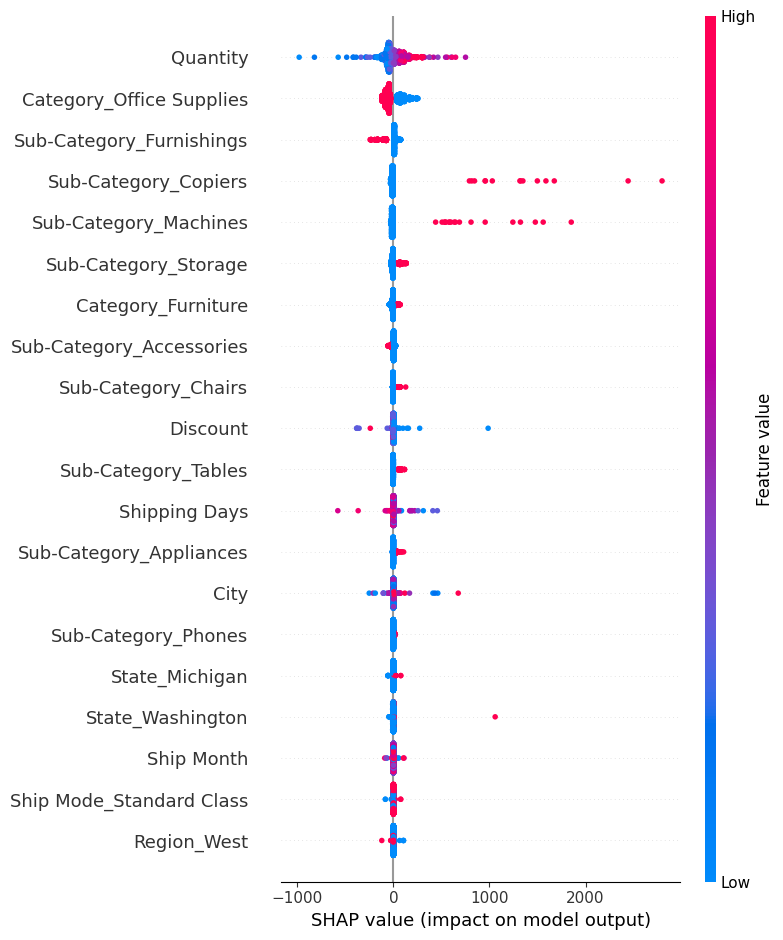

In [64]:
shap.summary_plot(
    shap_values,
    X_test
)

In [65]:
shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by='importance',
    ascending=False
)
shap_importance.reset_index(drop=True, inplace=True)

In [74]:
shap_importance[shap_importance['importance']==0.0].head()

,feature,importance
50,State_Arkansas,0.0
51,State_Colorado,0.0
52,State_Arizona,0.0
53,State_Alabama,0.0
54,Ship Mode_Same Day,0.0


## Fine tuning the What if model

In [69]:
model_sales2 = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, early_stopping_rounds=50
)
model_profit2 = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, early_stopping_rounds=50
)

In [67]:
zero_fi=shap_importance.query("importance == 0")["feature"].tolist()

- by training model without zero_fi I see absolute no change in accuracy, so final decision is to drop them

In [86]:
smlt_five_fi=shap_importance.query("importance <= 5")["feature"].tolist()

- outoff 88 cols, 79 have fi<=5, and by traing model without them the rmse and r2_score increases (RMSE: 640.1089, R2 score:  0.15300566873765054

In [106]:
smlt_two_fi=shap_importance.query("importance <= 2")["feature"].tolist()

In [107]:
X_train_2=X_train.drop(columns=smlt_two_fi)
X_test_2=X_test.drop(columns=smlt_two_fi)

In [108]:
model_sales.fit(X_train_2, y_train_sales, eval_set=[(X_test_2, y_test_sales)], verbose=50)

[0]	validation_0-rmse:689.77036
[50]	validation_0-rmse:655.83387
[69]	validation_0-rmse:661.27594


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [109]:
model_sales_pred=model_sales.predict(X_test_2)
# Evaluate
print("Sales RMSE:", mean_squared_error(y_test_sales, model_sales_pred)**0.5)
print("Sales R2 score: ",r2_score(y_test_sales,model_sales_pred))

Sales RMSE: 648.9419038480564
Sales R2 score:  0.12946880455313947


In [111]:
print(len(shap_importance['feature'].tolist()), len(smlt_two_fi), len(smlt_five_fi), len(zero_fi))

88 74 79 38


In [115]:
shap_importance['importance'].value_counts()

importance
0.000000     38
70.874001     1
73.701187     1
19.955555     1
18.800108     1
14.563122     1
9.593738      1
6.872615      1
6.328106      1
4.969990      1
4.856955      1
4.337976      1
4.220122      1
3.925841      1
1.681524      1
1.145415      1
0.968075      1
0.800371      1
26.121174     1
0.708703      1
0.688375      1
0.541227      1
0.674546      1
0.492882      1
0.491296      1
0.434754      1
0.506438      1
0.314138      1
0.310075      1
0.308934      1
0.284608      1
0.283231      1
0.264654      1
0.197611      1
0.326422      1
0.189001      1
0.166067      1
0.145809      1
0.160683      1
0.116791      1
0.091880      1
0.076492      1
0.145022      1
0.067489      1
0.060116      1
0.028436      1
0.040716      1
0.022635      1
0.011835      1
0.003328      1
0.001805      1
Name: count, dtype: int64